In [12]:
import numpy as np
import pandas as pd

# Importing files from the computer into the DataFrame
orders = pd.read_csv(r"D:\Oladimeji\Data Science\Assignments\Assignment 3\orders.csv")
order_details = pd.read_csv(r"D:\Oladimeji\Data Science\Assignments\Assignment 3\order_details.csv")
pizzas = pd.read_csv(r"D:\Oladimeji\Data Science\Assignments\Assignment 3\pizzas.csv")

import matplotlib.pyplot as plt

In [13]:
# Clearing the encoding errors utf-8 byreplacing any invalid character found and replace instead of causing error

pizza_types = pd.read_csv(r"D:\Oladimeji\Data Science\Assignments\Assignment 3\pizza_types.csv",encoding="utf-8",encoding_errors="replace")

In [14]:
# Checking the summary of the DataFrame orders

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  21350 non-null  int64 
 1   date      21350 non-null  object
 2   time      21350 non-null  object
dtypes: int64(1), object(2)
memory usage: 500.5+ KB


In [15]:
order_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_details_id  48620 non-null  int64 
 1   order_id          48620 non-null  int64 
 2   pizza_id          48620 non-null  object
 3   quantity          48620 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [16]:
pizzas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pizza_id       96 non-null     object 
 1   pizza_type_id  96 non-null     object 
 2   size           96 non-null     object 
 3   price          96 non-null     float64
dtypes: float64(1), object(3)
memory usage: 3.1+ KB


In [17]:
pizza_types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   pizza_type_id  32 non-null     object
 1   name           32 non-null     object
 2   category       32 non-null     object
 3   ingredients    32 non-null     object
dtypes: object(4)
memory usage: 1.1+ KB


In [18]:
orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [19]:
# Converting the date column to a datetime object

orders["date"] = pd.to_datetime(orders["date"])

In [20]:
# Keeping the time column as a datetime object

orders["time"] = pd.to_datetime(orders["time"], format = "%H:%M:%S")

In [21]:
# confirming the conversion of the data type

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   order_id  21350 non-null  int64         
 1   date      21350 non-null  datetime64[ns]
 2   time      21350 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1)
memory usage: 500.5 KB


In [22]:
# Using the pd.merge to merge orders and order_details into pizza_sales data frame
# Using the column order_id
# with inner merging to remove duplicate

pizza_sales = pd.merge(orders, order_details, on = "order_id", how = "inner")

In [23]:
# Confiming the merge

pizza_sales.head()

,order_id,date,time,order_details_id,pizza_id,quantity
0,1,2015-01-01,1900-01-01 11:38:36,1,hawaiian_m,1
1,2,2015-01-01,1900-01-01 11:57:40,2,classic_dlx_m,1
2,2,2015-01-01,1900-01-01 11:57:40,3,five_cheese_l,1
3,2,2015-01-01,1900-01-01 11:57:40,4,ital_supr_l,1
4,2,2015-01-01,1900-01-01 11:57:40,5,mexicana_m,1


In [24]:
# Using the pd.merge to merge pizza_sales and pizza into pizza_sales data frame
# Using the colum pizza_id_id
# With inner merging to remove duplicate

pizza_sales = pd.merge(pizza_sales, pizzas, on = "pizza_id", how = "inner")

In [25]:
# Confiming the merges

pizza_sales.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price
0,1,2015-01-01,1900-01-01 11:38:36,1,hawaiian_m,1,hawaiian,M,13.25
1,2,2015-01-01,1900-01-01 11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00
2,2,2015-01-01,1900-01-01 11:57:40,3,five_cheese_l,1,five_cheese,L,18.50
3,2,2015-01-01,1900-01-01 11:57:40,4,ital_supr_l,1,ital_supr,L,20.75
4,2,2015-01-01,1900-01-01 11:57:40,5,mexicana_m,1,mexicana,M,16.00


In [26]:
# Using the pd.merge to merge pizza_sales and pizza_type data frame
# Using the colum pizza_type_id
# With inner merging to remove duplicate

pizza_sales = pd.merge(pizza_sales, pizza_types, on = "pizza_type_id", how = "inner")

In [27]:
# Confiming the final merges

pizza_sales.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
0,1,2015-01-01,1900-01-01 11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2015-01-01,1900-01-01 11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,2,2015-01-01,1900-01-01 11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,2,2015-01-01,1900-01-01 11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,2,2015-01-01,1900-01-01 11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [28]:
# Checking the DataFrame summary of the merged DataFrames

pizza_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          48620 non-null  int64         
 1   date              48620 non-null  datetime64[ns]
 2   time              48620 non-null  datetime64[ns]
 3   order_details_id  48620 non-null  int64         
 4   pizza_id          48620 non-null  object        
 5   quantity          48620 non-null  int64         
 6   pizza_type_id     48620 non-null  object        
 7   size              48620 non-null  object        
 8   price             48620 non-null  float64       
 9   name              48620 non-null  object        
 10  category          48620 non-null  object        
 11  ingredients       48620 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(3), object(6)
memory usage: 4.5+ MB


In [29]:
# Rearranging the column names for better analysis

pizza_sales = pizza_sales[["order_id", "order_details_id", "date", "time", "pizza_id", "pizza_type_id", "name", "category", "size", "quantity", "price", "ingredients"]]

In [30]:
# Confirming the rearrangement

pizza_sales.head(3)

,order_id,order_details_id,date,time,pizza_id,pizza_type_id,name,category,size,quantity,price,ingredients
0,1,1,2015-01-01,1900-01-01 11:38:36,hawaiian_m,hawaiian,The Hawaiian Pizza,Classic,M,1,13.25,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,2015-01-01,1900-01-01 11:57:40,classic_dlx_m,classic_dlx,The Classic Deluxe Pizza,Classic,M,1,16.00,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,2,3,2015-01-01,1900-01-01 11:57:40,five_cheese_l,five_cheese,The Five Cheese Pizza,Veggie,L,1,18.50,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."


In [31]:
# Creating a sales column with the multiplication of quantity and price columns

pizza_sales["sales"] = pizza_sales["quantity"] * pizza_sales["price"]

In [32]:
# Confirmimg the creation of sales column

pizza_sales.head(3)

,order_id,order_details_id,date,time,pizza_id,pizza_type_id,name,category,size,quantity,price,ingredients,sales
0,1,1,2015-01-01,1900-01-01 11:38:36,hawaiian_m,hawaiian,The Hawaiian Pizza,Classic,M,1,13.25,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25
1,2,2,2015-01-01,1900-01-01 11:57:40,classic_dlx_m,classic_dlx,The Classic Deluxe Pizza,Classic,M,1,16.00,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00
2,2,3,2015-01-01,1900-01-01 11:57:40,five_cheese_l,five_cheese,The Five Cheese Pizza,Veggie,L,1,18.50,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50


#### 1. Total revenue/sales

In [33]:
# Creating a daily sales data frame with date and total sales per day by grouping
# all rows with the same date, get the column sales and add the sales value with each dates
# together and creating an index instead of using date column as an index

daily_sales = (pizza_sales.groupby("date")[["sales"]].sum().reset_index())

In [34]:
daily_sales.head()

,date,sales
0,2015-01-01,2713.85
1,2015-01-02,2731.90
2,2015-01-03,2662.40
3,2015-01-04,1755.45
4,2015-01-05,2065.95


In [35]:
# Adding all the sales to get the total revenue and formatting it to 2 Decimal Place

total_revenue = daily_sales["sales"].sum()

print(f"Total Revenue: ₦{total_revenue:,.2f}k")

Total Revenue: ₦817,860.05k


#### 2. Total quantity sold

In [36]:
# Getting all the numbers in quantity and adding the together

total_quantity = pizza_sales["quantity"].sum()

print(f"Total Quantity: {total_quantity}")

Total Quantity: 49574


#### 3. Total orders

In [37]:
# The order_id column will be used
# Some order_id have the same order_id because the order have multiple categories
# So, each numbers are unique
# Using .nunique() to group same id together to count only the distinct values

total_orders = pizza_sales["order_id"].nunique()
print(f"Total Orders: {total_orders}")

Total Orders: 21350


#### 4. Types of Pizza sold

In [38]:
# Group each row the have the same pizza type in the pizza type id column
# count how many row have the same pizza type id in each group
# Cereate an index number and save the count into a frequency column

pizza_types = (pizza_sales.groupby("pizza_type_id").size().reset_index(name="frequency"))
pizza_types

,pizza_type_id,frequency
0,bbq_ckn,2372
1,big_meat,1811
2,brie_carre,480
3,calabrese,927
4,cali_ckn,2302
5,ckn_alfredo,980
6,ckn_pesto,961
7,classic_dlx,2416
8,five_cheese,1359
9,four_cheese,1850


In [39]:
# Counting how many times each unique row occurs and adding them together

pizza_types_sold = pizza_types.value_counts().sum()

print(f"Number of Pizza Type Sold: {pizza_types_sold}")

Number of Pizza Type Sold: 32


#### 5. Average price of the pizzas

In [40]:
# Getting the mean of the price column and formating it into 2 Decimal places

average_price_of_the_pizzas = pizza_sales["price"].mean()

print(f"Average Price of the Pizza: ₦{average_price_of_the_pizzas:.2f}k")

Average Price of the Pizza: ₦16.49k


### OR

In [41]:
# Getting the sum of the price column

price_sum = pizza_sales["price"].sum()

print(f"Total Price of Sales: ₦{price_sum:.2f}k")

Total Price of Sales: ₦801944.70k


In [42]:
# Getting the total number of rows in price column

total_number = pizza_sales["price"].count()

print(f"Total number of the Pizza: {total_number}")

Total number of the Pizza: 48620


In [43]:
# Diving the total sales with number of rows

average_price_of_the_pizza = price_sum / total_number

print(f"Average Price of the Pizza: ₦{average_price_of_the_pizza:.2f}k")

Average Price of the Pizza: ₦16.49k


#### 6. Peak Sales Hour

In [44]:
# Creating column hour to know the hour the order was made
pizza_sales["hour"] = pizza_sales["time"].dt.hour

In [45]:
# Getting out hour and sales coulum from the data frame pizza sales and indexing it
# Sorting the table by sales in descending pattern
# Creating a variable name "peak hour" for the result

peak_hours = (pizza_sales.groupby("hour")["sales"].sum().reset_index().sort_values(by="sales", ascending=False))

peak_hours

,hour,sales
3,12,111877.90
4,13,106065.70
9,18,89296.85
8,17,86237.45
10,19,72628.90
7,16,70055.40
5,14,59201.40
11,20,58215.40
6,15,52992.30
2,11,44935.80


In [46]:
peak_hour = peak_hours.loc[peak_hours['sales'].idxmax(), 'hour'] # Getting out the peak hour without index
peak_value = peak_hours.loc[peak_hours['sales'].idxmax(), 'sales'] # Getting out the peak value without index

print(f"Peak Sales occurred at {peak_hour}:00PM which is the Lunch time and the Total Sales of ₦{peak_value:,.2f}k")

Peak Sales occurred at 12:00PM which is the Lunch time and the Total Sales of ₦111,877.90k


### Question 6 with Bar Chat

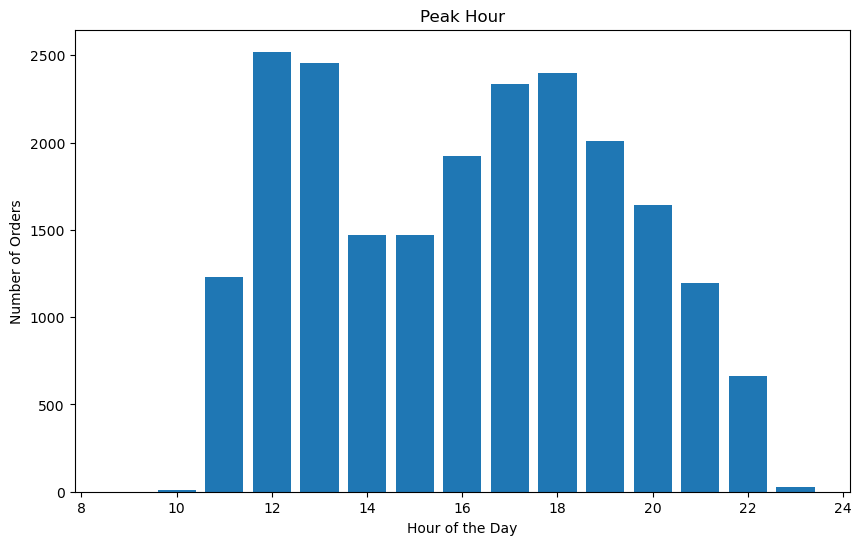

In [47]:
# Grouping according to the hour the order was made, select the order id column
# and count the numbers that appear more than one as a single row

hourly_sales = pizza_sales.groupby("hour")["order_id"].nunique()

plt.figure(figsize=(10,6))

plt.bar(hourly_sales.index,
        hourly_sales.values)

plt.title("Peak Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Orders")


plt.show()

#### 7. Days of the Week

In [48]:
pizza_sales.head(2)

,order_id,order_details_id,date,time,pizza_id,pizza_type_id,name,category,size,quantity,price,ingredients,sales,hour
0,1,1,2015-01-01,1900-01-01 11:38:36,hawaiian_m,hawaiian,The Hawaiian Pizza,Classic,M,1,13.25,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11
1,2,2,2015-01-01,1900-01-01 11:57:40,classic_dlx_m,classic_dlx,The Classic Deluxe Pizza,Classic,M,1,16.00,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11


In [49]:
# Extracting the days of the week from the date column in the dataframe Pizza Sales

pizza_sales["day_of_the_week"] = pizza_sales["date"].dt.day_name()

pizza_sales["day_of_the_week"]

0        Thursday
1        Thursday
2        Thursday
3        Thursday
4        Thursday
           ...   
48615    Thursday
48616    Thursday
48617    Thursday
48618    Thursday
48619    Thursday
Name: day_of_the_week, Length: 48620, dtype: object

In [50]:
# Grouping the days into rows with sales, adding up the sales with the same day
# together and arrange them from Sunday to Saturday

sales_per_day = (pizza_sales.groupby("day_of_the_week")["sales"]).sum().reindex(["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"])

sales_per_day

day_of_the_week
Sunday        99203.50
Monday       107329.55
Tuesday      114133.80
Wednesday    114408.40
Thursday     123528.50
Friday       136073.90
Saturday     123182.40
Name: sales, dtype: float64

In [51]:
highest_day = sales_per_day.idxmax() # To get out the highest sales day
highest_sales = sales_per_day.max() # To get out the highset sales value


print(f"The day in which the Sales are made the most is {highest_day} with Total Sales of ₦{highest_sales:,.2f}k")

The day in which the Sales are made the most is Friday with Total Sales of ₦136,073.90k


#### 8. Five Best Selling Pizza

In [52]:
pizza_sales.head(1)

,order_id,order_details_id,date,time,pizza_id,pizza_type_id,name,category,size,quantity,price,ingredients,sales,hour,day_of_the_week
0,1,1,2015-01-01,1900-01-01 11:38:36,hawaiian_m,hawaiian,The Hawaiian Pizza,Classic,M,1,13.25,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday


In [53]:
# First, group all the pizza name with a unique name
# Then add up the sales of the grouped pizza
# reset_index() makes the pizza name to be normal column rather than index
# sort_values() makes the highest sales to be on-top and least below

top_5_pizza = (pizza_sales.groupby("name")["sales"].sum().reset_index().sort_values("sales", ascending=False))

top_5_pizza.head()

,name,sales
30,The Thai Chicken Pizza,43434.25
0,The Barbecue Chicken Pizza,42768.00
4,The California Chicken Pizza,41409.50
7,The Classic Deluxe Pizza,38180.50
26,The Spicy Italian Pizza,34831.25


#### 9. Sales made in each month

In [54]:
# Getting the month from the date column into a dataframe monthly sales
# Grouping the month into rows with sales, adding up the sales with the same month
# together and arrange them from January to December

pizza_sales["monthly_sales"] = pizza_sales["date"].dt.month_name()
sales_by_months = (pizza_sales.groupby("monthly_sales")["sales"]).sum().reindex(["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"])
                                       

sales_by_months

monthly_sales
January      69793.30
February     65159.60
March        70397.10
April        68736.80
May          71402.75
June         68230.20
July         72557.90
August       68278.25
September    64180.05
October      64027.60
November     70395.35
December     64701.15
Name: sales, dtype: float64

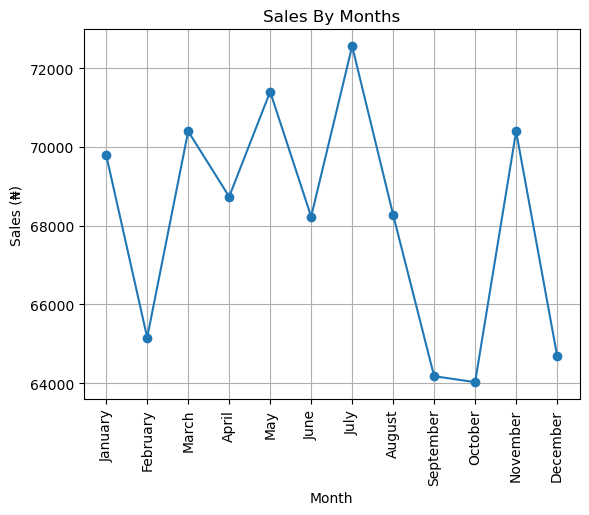

In [55]:
# Gettiing a line plots showing the sales per month

plt.plot(sales_by_months.index, sales_by_months.values, marker='o')
plt.title("Sales By Months")
plt.xlabel("Month")
plt.ylabel("Sales (₦)")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

Looking at the line plot, it shows that there is no significant dropnwhic means, their is no much changes in the sales, but there is an increase in sales during July, which is the beginning of summer holiday, where families travel out of their locality. Also in November, there is an increase based on the beginning of a yearly celebration, but dropped a little in December, where people prepare foods at home and visiting their families and loved ones at home rather than ordering pizza

#### 10. pizza types that are not doing well on the menu

In [56]:
pizza_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          48620 non-null  int64         
 1   order_details_id  48620 non-null  int64         
 2   date              48620 non-null  datetime64[ns]
 3   time              48620 non-null  datetime64[ns]
 4   pizza_id          48620 non-null  object        
 5   pizza_type_id     48620 non-null  object        
 6   name              48620 non-null  object        
 7   category          48620 non-null  object        
 8   size              48620 non-null  object        
 9   quantity          48620 non-null  int64         
 10  price             48620 non-null  float64       
 11  ingredients       48620 non-null  object        
 12  sales             48620 non-null  float64       
 13  hour              48620 non-null  int32         
 14  day_of_the_week   4862

In [57]:
pizza_sales.head(1)

,order_id,order_details_id,date,time,pizza_id,pizza_type_id,name,category,size,quantity,price,ingredients,sales,hour,day_of_the_week,monthly_sales
0,1,1,2015-01-01,1900-01-01 11:38:36,hawaiian_m,hawaiian,The Hawaiian Pizza,Classic,M,1,13.25,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday,January


In [58]:
# Grouping the pizza with the same name into a group and get the sales for each individual pizza
# Add the sales with the same group together, create an index and sort by sales in ascending order
# With this, you can get the lowest sales pizza

group_pizza = pizza_sales.groupby("name")["sales"].sum().reset_index().sort_values("sales")

group_pizza.head()

,name,sales
2,The Brie Carre Pizza,11588.50
11,The Green Garden Pizza,13955.75
28,The Spinach Supreme Pizza,15277.75
16,The Mediterranean Pizza,15360.50
27,The Spinach Pesto Pizza,15596.00


In [59]:
# Getting the value of the lowest sales pizza

lowest = group_pizza.iloc[0]

print(f"Lowest-selling pizza is {lowest['name']} with Total Sales ₦{lowest["sales"]:,.2f}k")

Lowest-selling pizza is The Brie Carre Pizza with Total Sales ₦11,588.50k
